In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random

In [3]:
G = pd.read_csv('calls.csv')
G = nx.from_pandas_edgelist(G, 'caller', 'callee', ['duration', 'timestamp'], create_using=nx.DiGraph())
G.remove_edges_from(nx.selfloop_edges(G))
isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)
threshold = 0.5
edges_to_remove = [(u, v) for u, v, d in G.edges(data=True) if d.get("weight", 1) < threshold]
G.remove_edges_from(edges_to_remove)

SI with Randomly starting node

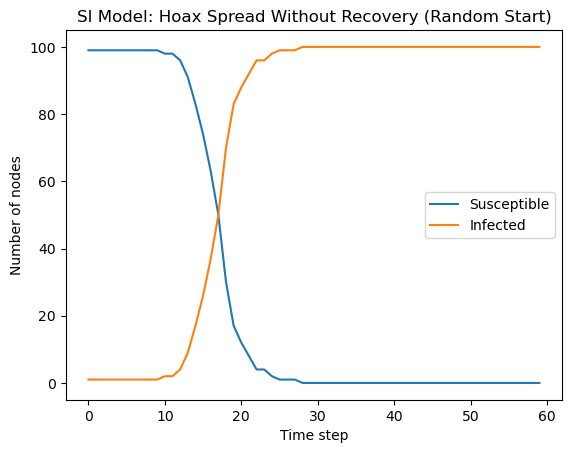

In [10]:
def simulate_si_model(G, beta=0.2, steps=50, seed_count=1, min_size=5):
    # Extract largest connected component
    if G.is_directed():
        largest_cc = max(nx.weakly_connected_components(G), key=len)
    else:
        largest_cc = max(nx.connected_components(G), key=len)

    # Optionally ignore tiny components
    if len(largest_cc) < min_size:
        raise ValueError("Largest component too small, try a bigger graph or lower min_size.")

    G_lcc = G.subgraph(largest_cc).copy()

    # Initialize states: 0 = Susceptible, 1 = Infected
    state = {n: 0 for n in G_lcc.nodes()}

    # 🔑 Infect seed nodes chosen randomly instead of hubs
    seeds = random.sample(list(G_lcc.nodes()), seed_count)
    for node in seeds:
        state[node] = 1

    S, I = [], []

    for t in range(steps):
        new_state = state.copy()
        for node in G_lcc.nodes():
            if state[node] == 1:
                neighbors = G_lcc.successors(node) if G_lcc.is_directed() else G_lcc.neighbors(node)
                for neigh in neighbors:
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
        state = new_state
        S.append(sum(1 for v in state.values() if v == 0))
        I.append(sum(1 for v in state.values() if v == 1))

    return S, I

# Example run
G = nx.erdos_renyi_graph(100, 0.05)
S, I = simulate_si_model(G, beta=0.2, steps=60, seed_count=1)

plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected")
plt.xlabel("Time step")
plt.ylabel("Number of nodes")
plt.legend()
plt.title("SI Model: Hoax Spread Without Recovery (Random Start)")
plt.show()

SIC with Randomly starting node

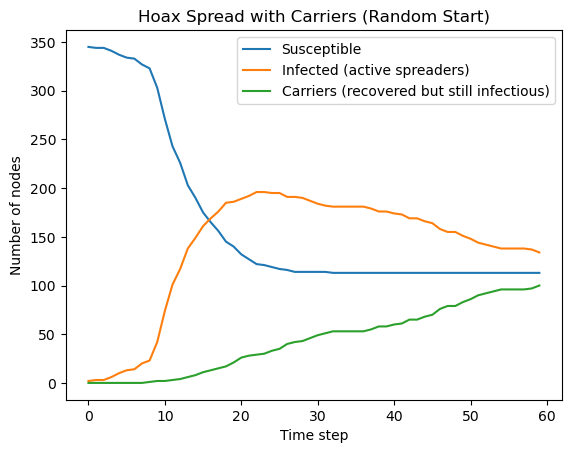

In [6]:
def simulate_hoax_with_carriers(G, beta=0.3, gamma=0.05, steps=50, min_size=5):
    # Extract largest component (or filter small ones)
    if G.is_directed():
        largest_cc = max(nx.weakly_connected_components(G), key=len)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
    
    # Optionally ignore tiny components
    if len(largest_cc) < min_size:
        raise ValueError("Largest component too small, try a bigger graph or lower min_size.")
    
    G_lcc = G.subgraph(largest_cc).copy()

    # States: 0=S, 1=I, 2=C (carrier)
    state = {n: 0 for n in G_lcc.nodes()}

    # 🔑 Randomly choose starting node instead of hub
    start_node = random.choice(list(G_lcc.nodes()))
    state[start_node] = 1

    S, I, C = [], [], []

    for t in range(steps):
        new_state = state.copy()
        for node in G_lcc.nodes():
            if state[node] in [1, 2]:  # infected or carrier
                for neigh in G_lcc.neighbors(node):
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
            if state[node] == 1:  # infected can become carrier
                if random.random() < gamma:
                    new_state[node] = 2
        state = new_state

        S.append(sum(1 for v in state.values() if v == 0))
        I.append(sum(1 for v in state.values() if v == 1))
        C.append(sum(1 for v in state.values() if v == 2))

    return S, I, C

S, I, C = simulate_hoax_with_carriers(G, beta=0.5, gamma=0.01, steps=60)

plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected (active spreaders)")
plt.plot(C, label="Carriers (recovered but still infectious)")
plt.xlabel("Time step")
plt.ylabel("Number of nodes")
plt.legend()
plt.title("Hoax Spread with Carriers (Random Start)")
plt.show()

SIS model with random start 

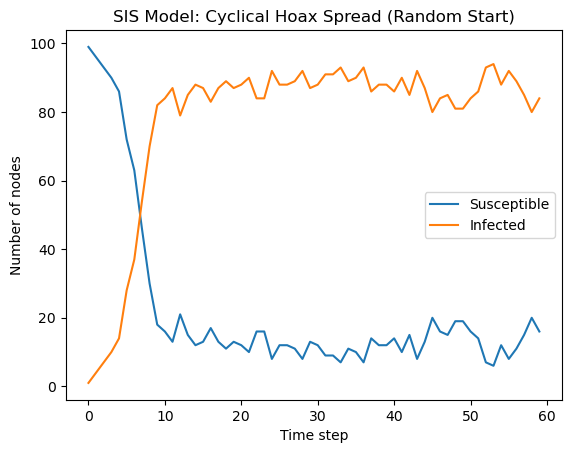

In [11]:
def simulate_sis_model(G, beta=0.3, gamma=0.1, steps=60, seed_count=1, min_size=5):
    # Extract largest connected component
    if G.is_directed():
        largest_cc = max(nx.weakly_connected_components(G), key=len)
    else:
        largest_cc = max(nx.connected_components(G), key=len)

    # Optionally ignore tiny components
    if len(largest_cc) < min_size:
        raise ValueError("Largest component too small, try a bigger graph or lower min_size.")

    G_lcc = G.subgraph(largest_cc).copy()

    # Initialize states: 0 = Susceptible, 1 = Infected
    state = {n: 0 for n in G_lcc.nodes()}

    # 🔑 Infect seed nodes chosen randomly instead of hubs
    seeds = random.sample(list(G_lcc.nodes()), seed_count)
    for node in seeds:
        state[node] = 1

    S, I = [], []

    for t in range(steps):
        new_state = state.copy()
        for node in G_lcc.nodes():
            if state[node] == 1:
                neighbors = G_lcc.successors(node) if G_lcc.is_directed() else G_lcc.neighbors(node)
                for neigh in neighbors:
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
                # Recovery step
                if random.random() < gamma:
                    new_state[node] = 0
        state = new_state
        S.append(sum(1 for v in state.values() if v == 0))
        I.append(sum(1 for v in state.values() if v == 1))

    return S, I

S, I = simulate_sis_model(G, beta=0.3, gamma=0.1, steps=60, seed_count=1)

plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected")
plt.xlabel("Time step")
plt.ylabel("Number of nodes")
plt.legend()
plt.title("SIS Model: Cyclical Hoax Spread (Random Start)")
plt.show()

SIR model with random start

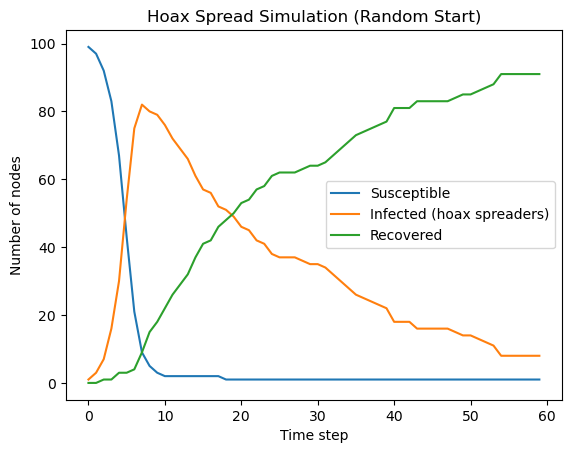

In [ ]:
def get_largest_component(G, min_size=5):
    if G.is_directed():
        largest_cc = max(nx.weakly_connected_components(G), key=len)
    else:
        largest_cc = max(nx.connected_components(G), key=len)

    if len(largest_cc) < min_size:
        raise ValueError("Largest component too small, try a bigger graph or lower min_size.")

    return G.subgraph(largest_cc).copy()

def simulate_hoax(G, beta=0.3, gamma=0.05, steps=50, seed_count=1):
    # Extract largest component
    G_lcc = get_largest_component(G)

    # Initialize states: 0=S, 1=I, 2=R
    state = {n: 0 for n in G_lcc.nodes()}

    # 🔑 Infect random seed nodes instead of hub
    seeds = random.sample(list(G_lcc.nodes()), seed_count)
    for node in seeds:
        state[node] = 1

    # Track counts
    S, I, R = [], [], []

    for t in range(steps):
        new_state = state.copy()
        for node in G_lcc.nodes():
            if state[node] == 1:  # infected
                # Try to infect neighbors
                for neigh in G_lcc.neighbors(node):
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
                # Recovery
                if random.random() < gamma:
                    new_state[node] = 2
        state = new_state

        # Count states
        S.append(sum(1 for v in state.values() if v == 0))
        I.append(sum(1 for v in state.values() if v == 1))
        R.append(sum(1 for v in state.values() if v == 2))

    return S, I, R

# Example run
G = nx.erdos_renyi_graph(100, 0.05)
S, I, R = simulate_hoax(G, beta=0.3, gamma=0.05, steps=60, seed_count=1)

plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected (hoax spreaders)")
plt.plot(R, label="Recovered")
plt.xlabel("Time step")
plt.ylabel("Number of nodes")
plt.legend()
plt.title("Hoax Spread Simulation (Random Start)")
plt.show()